In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================================
#  SAPA — PEMBANDING "KEPALA JATUH": Majority + RandomForest + MLP + 1D-CNN
#  CV & split IDENTIK train_fall.py / train_fall_stgcn.py (SEED sama) -> ADIL.
# ----------------------------------------------------------------------------
#  Tujuan: lengkapi tabel "Kematangan Arsitektur" dgn pembanding lintas keluarga:
#    Majority (lantai) · RandomForest (ML klasik) · MLP (NN dasar) · 1D-CNN (CNN)
#  CELL terakhir MENGGABUNGKAN otomatis dgn BiLSTM & ST-GCN -> satu tabel penuh.
#  Input: ntu_fall.npz. Output: fall_baselines_* + tabel perbandingan lengkap.
#  Copy tiap "# ===== CELL N =====" ke satu cell Colab. GPU disarankan (RF pakai CPU).
# ============================================================================


# ===== CELL 1: Import + Konfigurasi =====
import os, re, json, numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             recall_score, matthews_corrcoef, cohen_kappa_score,
                             confusion_matrix)
import pandas as pd
import matplotlib.pyplot as plt

BASE      = "/content/drive/MyDrive/Belajar AI/Compfest/Dataset"
NPZ_PATH  = f"{BASE}/preprocessed_2/ntu_fall.npz"
MODEL_DIR = f"{BASE}/models"; os.makedirs(MODEL_DIR, exist_ok=True)

FALL_JOINTS = list(range(5, 17)); USE_CHANNELS = 2
CLASS_NAMES = ["normal", "oleng", "jatuh"]; N_CLASSES = 3
METRIC_COLS = ["acc", "bal_acc", "macroF1", "weightedF1", "recall_jatuh", "mcc", "kappa"]
SEED, BATCH, EPOCHS, PATIENCE, N_FOLDS = 42, 128, 40, 8, 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)




Device: cpu


In [3]:
# ===== CELL 2: Load data + slice + grup performer =====
d = np.load(NPZ_PATH, allow_pickle=True)
kp = d["keypoints"]; y = d["labels"].astype(np.int64); meta = d["meta"].astype(str)
N = kp.shape[0]
Xseq  = kp[:, :, FALL_JOINTS, :USE_CHANNELS].reshape(N, kp.shape[1], -1).astype(np.float32)  # [N,45,24]
Xflat = Xseq.reshape(N, -1)                                                                   # [N,1080] utk RF
def performer(s):
    m = re.search(r'P(\d{3})', s); return m.group(0) if m else 'P000'
groups = np.array([performer(m) for m in meta])
print(f"Xseq {Xseq.shape} | Xflat {Xflat.shape} | performer {len(set(groups))}")
print("distribusi:", {CLASS_NAMES[c]: int((y==c).sum()) for c in range(N_CLASSES)})




Xseq (23964, 45, 24) | Xflat (23964, 1080) | performer 40
distribusi: {'normal': 15336, 'oleng': 4816, 'jatuh': 3812}


In [4]:
# ===== CELL 3: Model NN (MLP, 1D-CNN) + fungsi bantu =====
class MLP(nn.Module):
    def __init__(self, din, n):
        super().__init__(); self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(din, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, n))
    def forward(self, x): return self.net(x)

class CNN1D(nn.Module):
    def __init__(self, cin, n):
        super().__init__(); self.net = nn.Sequential(
            nn.Conv1d(cin, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n))
    def forward(self, x): return self.net(x.permute(0, 2, 1))   # [N,T,C]->[N,C,T]

def full_metrics(yt, yp):
    return {"acc": accuracy_score(yt, yp), "bal_acc": balanced_accuracy_score(yt, yp),
            "macroF1": f1_score(yt, yp, average='macro', zero_division=0),
            "weightedF1": f1_score(yt, yp, average='weighted', zero_division=0),
            "recall_jatuh": recall_score(yt, yp, labels=[2], average='macro', zero_division=0),
            "mcc": matthews_corrcoef(yt, yp), "kappa": cohen_kappa_score(yt, yp)}

def train_torch(build_fn, tr, va):
    cnt = np.bincount(y[tr], minlength=N_CLASSES).astype(np.float32)
    cw  = torch.tensor(cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None)), device=DEVICE)
    model = build_fn().to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw); opt = torch.optim.Adam(model.parameters(), 1e-3, weight_decay=1e-4)
    dl = DataLoader(TensorDataset(torch.tensor(Xseq[tr]), torch.tensor(y[tr])),
                    batch_size=BATCH, shuffle=True, drop_last=True)
    Xva = torch.tensor(Xseq[va], device=DEVICE)
    best, wait, best_state = -1, 0, None
    for ep in range(EPOCHS):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
        model.eval()
        with torch.no_grad(): pv = model(Xva).argmax(1).cpu().numpy()
        f1 = f1_score(y[va], pv, average='macro', zero_division=0)
        if f1 > best: best, wait, best_state = f1, 0, {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad(): return model(Xva).argmax(1).cpu().numpy()

def rf_fold(tr, va):
    rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                class_weight="balanced").fit(Xflat[tr], y[tr])
    return rf.predict(Xflat[va])




In [5]:
# ===== CELL 4: 5-Fold CV untuk ke-4 pembanding =====
MODELS = ["Majority", "RandomForest", "MLP", "1D-CNN"]
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof  = {m: -np.ones(N, np.int64) for m in MODELS}
rows = {m: [] for m in MODELS}
for fold, (tr, va) in enumerate(sgkf.split(Xflat, y, groups)):
    assert set(groups[tr]).isdisjoint(set(groups[va]))
    print(f"\n=== FOLD {fold} | train {len(tr)} / val {len(va)} ===")
    preds = {
        "Majority":     np.full(len(va), int(np.bincount(y[tr]).argmax())),
        "RandomForest": rf_fold(tr, va),
        "MLP":          train_torch(lambda: MLP(Xseq.shape[1]*Xseq.shape[2], N_CLASSES), tr, va),
        "1D-CNN":       train_torch(lambda: CNN1D(Xseq.shape[2], N_CLASSES), tr, va),
    }
    for m in MODELS:
        oof[m][va] = preds[m]; rows[m].append({"fold": fold, **full_metrics(y[va], preds[m])})
        print(f"  {m:13s}: macroF1 {rows[m][-1]['macroF1']:.3f} | recall_jatuh {rows[m][-1]['recall_jatuh']:.3f}")





=== FOLD 0 | train 19420 / val 4544 ===
  Majority     : macroF1 0.264 | recall_jatuh 0.000
  RandomForest : macroF1 0.803 | recall_jatuh 0.732
  MLP          : macroF1 0.845 | recall_jatuh 0.899
  1D-CNN       : macroF1 0.809 | recall_jatuh 0.853

=== FOLD 1 | train 21372 / val 2592 ===
  Majority     : macroF1 0.258 | recall_jatuh 0.000
  RandomForest : macroF1 0.842 | recall_jatuh 0.681
  MLP          : macroF1 0.880 | recall_jatuh 0.870
  1D-CNN       : macroF1 0.824 | recall_jatuh 0.853

=== FOLD 2 | train 19944 / val 4020 ===
  Majority     : macroF1 0.262 | recall_jatuh 0.000
  RandomForest : macroF1 0.827 | recall_jatuh 0.755
  MLP          : macroF1 0.864 | recall_jatuh 0.816
  1D-CNN       : macroF1 0.821 | recall_jatuh 0.696

=== FOLD 3 | train 18676 / val 5288 ===
  Majority     : macroF1 0.262 | recall_jatuh 0.000
  RandomForest : macroF1 0.768 | recall_jatuh 0.657
  MLP          : macroF1 0.829 | recall_jatuh 0.797
  1D-CNN       : macroF1 0.738 | recall_jatuh 0.870

===


================= TABEL PERBANDINGAN KEPALA JATUH =================
                        acc        bal_acc        macroF1     weightedF1   recall_jatuh            mcc          kappa
Majority      0.641 ± 0.011  0.333 ± 0.000  0.260 ± 0.003  0.501 ± 0.014  0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000
RandomForest  0.843 ± 0.028  0.750 ± 0.048  0.792 ± 0.043  0.834 ± 0.035  0.703 ± 0.035  0.688 ± 0.055  0.671 ± 0.067
MLP           0.875 ± 0.018  0.853 ± 0.024  0.848 ± 0.022  0.876 ± 0.018  0.842 ± 0.037  0.764 ± 0.034  0.764 ± 0.034
1D-CNN        0.826 ± 0.037  0.820 ± 0.017  0.798 ± 0.032  0.829 ± 0.034  0.825 ± 0.065  0.691 ± 0.043  0.683 ± 0.051
BiLSTM        0.903 ± 0.016  0.879 ± 0.023  0.878 ± 0.020  0.902 ± 0.017  0.867 ± 0.014  0.815 ± 0.031  0.814 ± 0.031
ST-GCN        0.900 ± 0.029  0.884 ± 0.020  0.878 ± 0.031  0.900 ± 0.028  0.909 ± 0.035  0.813 ± 0.049  0.811 ± 0.050

(Salin tabel ini ke bab 'Kematangan Arsitektur' di proposal.)


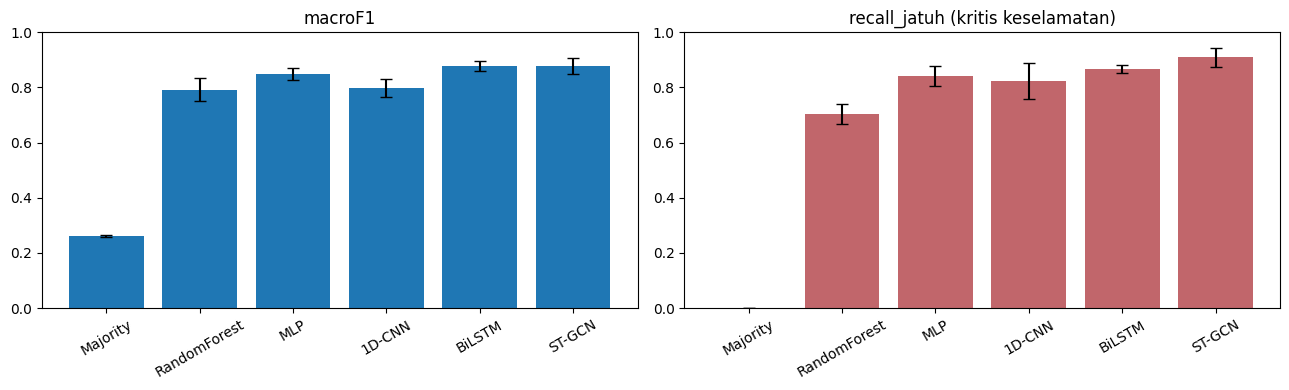

Tersimpan: fall_comparison_table.csv, fall_comparison_summary.json, fall_comparison.png


In [6]:
# ===== CELL 5: Ringkasan + GABUNG dgn BiLSTM & ST-GCN -> tabel lengkap =====
def summ(mrows):
    df = pd.DataFrame(mrows)
    return {k: {"mean": round(float(df[k].mean()), 4), "std": round(float(df[k].std(ddof=0)), 4)} for k in METRIC_COLS}

all_summ = {m: summ(rows[m]) for m in MODELS}
# tambahkan BiLSTM & ST-GCN dari file yang sudah ada (jika tersedia)
for name, path in [("BiLSTM", f"{MODEL_DIR}/fall_cv_summary.json"),
                   ("ST-GCN", f"{MODEL_DIR}/fall_stgcn_cv_summary.json")]:
    if os.path.exists(path):
        all_summ[name] = json.load(open(path))["summary_mean_std"]
    else:
        print(f"[info] {name} belum ada ({os.path.basename(path)}) — jalankan scriptnya utk masuk tabel.")

order = ["Majority", "RandomForest", "MLP", "1D-CNN", "BiLSTM", "ST-GCN"]
order = [m for m in order if m in all_summ]

# tabel (baris = model, kolom = metrik "mean±std")
tbl = pd.DataFrame({k: {m: f"{all_summ[m][k]['mean']:.3f} ± {all_summ[m][k]['std']:.3f}" for m in order}
                    for k in METRIC_COLS}).loc[order]
print("\n================= TABEL PERBANDINGAN KEPALA JATUH =================")
print(tbl.to_string())
print("\n(Salin tabel ini ke bab 'Kematangan Arsitektur' di proposal.)")

# simpan
pd.concat([pd.DataFrame(rows[m]).assign(model=m) for m in MODELS]).to_csv(
    f"{MODEL_DIR}/fall_baselines_folds.csv", index=False)
tbl.to_csv(f"{MODEL_DIR}/fall_comparison_table.csv")
with open(f"{MODEL_DIR}/fall_comparison_summary.json", "w") as f:
    json.dump({m: all_summ[m] for m in order}, f, indent=2)

# grafik: macroF1 & recall_jatuh semua model
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
mf = [all_summ[m]["macroF1"]["mean"] for m in order]
mfe = [all_summ[m]["macroF1"]["std"] for m in order]
rj = [all_summ[m]["recall_jatuh"]["mean"] for m in order]
rje = [all_summ[m]["recall_jatuh"]["std"] for m in order]
ax[0].bar(order, mf, yerr=mfe, capsize=4); ax[0].set_ylim(0, 1); ax[0].set_title("macroF1"); ax[0].tick_params(axis='x', rotation=30)
ax[1].bar(order, rj, yerr=rje, capsize=4, color="#c1666b"); ax[1].set_ylim(0, 1); ax[1].set_title("recall_jatuh (kritis keselamatan)"); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(f"{MODEL_DIR}/fall_comparison.png", dpi=120); plt.show()
print(f"Tersimpan: fall_comparison_table.csv, fall_comparison_summary.json, fall_comparison.png")